In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
import numpy as np
import itertools
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

In [ ]:
df = pd.read_csv("carbon_trading_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
df = df.sort_values(by='Date')
df_dum = df.copy()

# one hot encoding
df = pd.get_dummies(df, columns=["Industry_Type", "Fuel_Type", "Transaction_Type", "Verification_Status", "Optimization_Scenario"])
df

,Company_ID,Date,Energy_Demand_MWh,Emission_Produced_tCO2,Emission_Allowance_tCO2,Carbon_Price_USD_per_t,Credits_Traded_tCO2,Compliance_Cost_USD,Carbon_Cost_Savings_USD,Target_Trade_Action,...,Fuel_Type_Mixed Fuel,Fuel_Type_Natural Gas,Fuel_Type_Renewable,Transaction_Type_Buy,Transaction_Type_Sell,Verification_Status_Disputed,Verification_Status_Verified,Optimization_Scenario_High_Demand,Optimization_Scenario_Low_Demand,Optimization_Scenario_Price_Surge
1107,C033,2024-01-01,1725.44,1164.27,1181.27,22.42,165,7094.64,2045.22,1,...,False,False,True,True,False,False,True,True,False,False
559,C086,2024-01-01,2114.09,988.02,964.02,31.14,41,10865.67,893.75,1,...,False,True,False,True,False,False,True,False,False,True
4848,C096,2024-01-01,646.63,210.49,241.49,27.27,53,18491.80,2640.20,0,...,True,False,False,False,True,False,True,False,False,True
3257,C022,2024-01-01,1060.05,419.74,474.74,33.52,141,11179.34,2598.28,1,...,False,False,True,True,False,True,False,True,False,False
274,C027,2024-01-01,2851.41,1450.95,1369.95,30.95,30,9303.50,2655.93,0,...,True,False,False,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,C058,2025-12-31,842.76,533.95,350.95,24.57,88,14267.78,977.69,1,...,True,False,False,True,False,False,True,False,False,True
1140,C061,2025-12-31,1321.28,609.30,799.30,34.55,91,7686.45,1393.14,0,...,False,False,True,False,True,True,False,False,False,True
1500,C092,2025-12-31,2394.34,870.96,726.96,31.59,177,7228.84,2686.09,1,...,False,False,False,True,False,False,True,False,True,False
4827,C051,2025-12-31,2667.80,1564.28,1475.28,29.90,183,6944.08,2374.54,0,...,False,False,False,False,True,False,True,False,False,True


```carbon prices differ across the same market. law of one price - resolve transaction costs. however, when we standardize the data, it should not matter.```

 ```cointegration is often used to determine the feasibility of arbitrage (sheng et al)```

 ```week 1: finalize dataset & conduct exploratory cointegration analyses```

In [ ]:
# instructions [do not delete]

# step 0: take the log of both time series
# step 1: check the ADF value, and if the ADF value is > p[0.05], then the time series is non-stationary
# step 2: do this for both time series - this is a prerequisite for cointegration test
# step 3: do cointegration test - this (behind the hood) looks at the linear regression of residuals (so cool)
# step 4: now if the cointegration score is < p[0.05], then the time series are co-integrated
# step 5: if the time series are co-integrated, then by (sheng et al) we can test for arbitrage

In [ ]:
df_logarithmic = df.copy()
df_logarithmic['Energy_Demand_MWh'] = np.log1p(df_logarithmic['Energy_Demand_MWh'])
df_logarithmic['Emission_Produced_tCO2'] = np.log1p(df_logarithmic['Emission_Produced_tCO2'])
df_logarithmic['Emission_Allowance_tCO2'] = np.log1p(df_logarithmic['Emission_Allowance_tCO2'])
df_logarithmic['Carbon_Price_USD_per_t'] = np.log1p(df_logarithmic['Carbon_Price_USD_per_t'])
df_logarithmic['Credits_Traded_tCO2'] = np.log1p(df_logarithmic['Credits_Traded_tCO2'])
df_logarithmic['Compliance_Cost_USD'] = np.log1p(df_logarithmic['Compliance_Cost_USD'])
df_logarithmic['Carbon_Cost_Savings_USD'] = np.log1p(df_logarithmic['Carbon_Cost_Savings_USD'])

In [ ]:
# create dict

list_indus_type = ['Steel', 'Energy', 'Cement', 'Manufacturing']
list_fuel_type = ['Coal', 'Renewable', 'Mixed Fuel', 'Natural Gas']
list_trans_type = ['Buy', 'Sell']
list_verification = ['Verified', 'Disputed']
list_optimization = ['Price_Surge', 'High_Demand', 'Low_Demand']

columns_to_test = [
    'Energy_Demand_MWh', 'Emission_Produced_tCO2', 'Emission_Allowance_tCO2',
    'Carbon_Price_USD_per_t', 'Credits_Traded_tCO2', 'Compliance_Cost_USD',
    'Carbon_Cost_Savings_USD'
]

all_results = []

for i in list_indus_type:
    for j in list_fuel_type:
        for k in list_trans_type:
            for l in list_verification:
                for m in list_optimization:
                  df_temp = df_logarithmic[(df['Industry_Type'] == i) & (df['Fuel_Type'] == j) & (df['Transaction_Type'] == k) & (df['Verification_Status'] == l) & (df['Optimization_Scenario'] == m)]

                  if df_temp.empty:
                      continue

                  result_dict = {
                      'Industry_Type': i,
                      'Fuel_Type': j,
                      'Transaction_Type': k,
                      'Verification_Status': l,
                      'Optimization_Scenario': m
                  }

                  for col in columns_to_test:
                      adf_p_value = adfuller(df_temp[col])[1]
                      result_dict[f'{col}_p_value'] = adf_p_value

                  all_results.append(result_dict)

results_df = pd.DataFrame(all_results)
results_df

,Industry_Type,Fuel_Type,Transaction_Type,Verification_Status,Optimization_Scenario,Energy_Demand_MWh_p_value,Emission_Produced_tCO2_p_value,Emission_Allowance_tCO2_p_value,Carbon_Price_USD_per_t_p_value,Credits_Traded_tCO2_p_value,Compliance_Cost_USD_p_value,Carbon_Cost_Savings_USD_p_value
0,Steel,Coal,Buy,Verified,Price_Surge,9.939703e-01,4.151142e-01,3.653438e-02,5.445826e-01,2.605137e-28,2.636709e-08,2.692283e-02
1,Steel,Coal,Buy,Verified,High_Demand,8.660132e-01,6.503978e-01,4.256417e-04,5.392302e-03,1.594989e-01,2.295144e-01,7.217216e-02
2,Steel,Coal,Buy,Verified,Low_Demand,3.090861e-04,7.525777e-04,6.607090e-05,4.356526e-06,3.945916e-01,1.344941e-01,7.393363e-01
3,Steel,Coal,Buy,Disputed,Price_Surge,7.180805e-01,4.839471e-06,3.193224e-06,2.293364e-04,8.984604e-08,2.107194e-10,2.324810e-08
4,Steel,Coal,Buy,Disputed,High_Demand,5.546711e-06,1.555730e-01,4.376522e-01,2.633109e-05,1.637950e-08,3.773624e-01,2.292320e-03
...,...,...,...,...,...,...,...,...,...,...,...,...
187,Manufacturing,Natural Gas,Sell,Verified,High_Demand,4.750940e-02,2.707575e-04,8.465082e-04,3.527795e-07,1.294325e-07,4.400241e-08,4.401069e-11
188,Manufacturing,Natural Gas,Sell,Verified,Low_Demand,6.858397e-07,1.237893e-08,7.046088e-09,8.894956e-08,6.026107e-08,5.282407e-06,2.921627e-01
189,Manufacturing,Natural Gas,Sell,Disputed,Price_Surge,9.145537e-01,6.748046e-06,2.774867e-02,0.000000e+00,1.641912e-08,1.491245e-03,2.227118e-01
190,Manufacturing,Natural Gas,Sell,Disputed,High_Demand,1.693417e-05,4.441298e-02,3.675584e-02,8.704979e-01,9.734484e-02,6.883720e-03,3.615024e-03


In [ ]:
def color_p_values(val):
    if isinstance(val, (float, np.float64)):
        if val > 0.005:
            color = 'limegreen'
        else:
            color = 'lightcoral'
        return f'background-color: {color}'
    return ''

In [ ]:
styled_df = results_df.style.applymap(
    color_p_values,
    subset=['Energy_Demand_MWh_p_value', 'Emission_Produced_tCO2_p_value', 'Emission_Allowance_tCO2_p_value',
    'Carbon_Price_USD_per_t_p_value', 'Credits_Traded_tCO2_p_value', 'Compliance_Cost_USD_p_value',
    'Carbon_Cost_Savings_USD_p_value']
)
styled_df

/tmp/ipython-input-3169828443.py:1: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = results_df.style.applymap(


,Industry_Type,Fuel_Type,Transaction_Type,Verification_Status,Optimization_Scenario,Energy_Demand_MWh_p_value,Emission_Produced_tCO2_p_value,Emission_Allowance_tCO2_p_value,Carbon_Price_USD_per_t_p_value,Credits_Traded_tCO2_p_value,Compliance_Cost_USD_p_value,Carbon_Cost_Savings_USD_p_value
0,Steel,Coal,Buy,Verified,Price_Surge,0.993970,0.415114,0.036534,0.544583,0.000000,0.000000,0.026923
1,Steel,Coal,Buy,Verified,High_Demand,0.866013,0.650398,0.000426,0.005392,0.159499,0.229514,0.072172
2,Steel,Coal,Buy,Verified,Low_Demand,0.000309,0.000753,0.000066,0.000004,0.394592,0.134494,0.739336
3,Steel,Coal,Buy,Disputed,Price_Surge,0.718081,0.000005,0.000003,0.000229,0.000000,0.000000,0.000000
4,Steel,Coal,Buy,Disputed,High_Demand,0.000006,0.155573,0.437652,0.000026,0.000000,0.377362,0.002292
5,Steel,Coal,Buy,Disputed,Low_Demand,0.000000,0.555467,0.180135,0.000022,0.000037,0.000000,0.000000
6,Steel,Coal,Sell,Verified,Price_Surge,0.000000,0.000000,0.000000,0.023060,0.000027,0.000001,0.000758
7,Steel,Coal,Sell,Verified,High_Demand,0.022166,0.006793,0.001918,0.000000,0.045225,0.002643,0.902475
8,Steel,Coal,Sell,Verified,Low_Demand,0.000000,0.000000,0.000010,0.000349,0.000000,0.007746,0.996995
9,Steel,Coal,Sell,Disputed,Price_Surge,0.002705,0.040227,0.088531,0.189570,0.019298,0.063776,0.138643


``` i am looking at the dataset as a whole```

In [ ]:
columns_to_test = [
    'Energy_Demand_MWh', 'Emission_Produced_tCO2', 'Emission_Allowance_tCO2',
    'Carbon_Price_USD_per_t', 'Credits_Traded_tCO2', 'Compliance_Cost_USD',
    'Carbon_Cost_Savings_USD'
]

global_all_results = []

df_temp = df_logarithmic

new_result_dict = {}

for col in columns_to_test:
    adf_p_value = adfuller(df_temp[col])[1]
    new_result_dict[f'{col}_p_value'] = adf_p_value

global_all_results.append(new_result_dict)
global_results_df = pd.DataFrame(global_all_results)

global_styled_df = global_results_df.style.applymap(
    color_p_values,
    subset=['Energy_Demand_MWh_p_value', 'Emission_Produced_tCO2_p_value', 'Emission_Allowance_tCO2_p_value',
    'Carbon_Price_USD_per_t_p_value', 'Credits_Traded_tCO2_p_value', 'Compliance_Cost_USD_p_value',
    'Carbon_Cost_Savings_USD_p_value']
)
global_styled_df

/tmp/ipython-input-372810395.py:21: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  global_styled_df = global_results_df.style.applymap(


,Energy_Demand_MWh_p_value,Emission_Produced_tCO2_p_value,Emission_Allowance_tCO2_p_value,Carbon_Price_USD_per_t_p_value,Credits_Traded_tCO2_p_value,Compliance_Cost_USD_p_value,Carbon_Cost_Savings_USD_p_value
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
# conduct cointegration and make the dataframe with results

cointegration_results = []

for col1, col2 in itertools.combinations(columns_to_test, 2):

    series1 = df_logarithmic[col1].dropna()
    series2 = df_logarithmic[col2].dropna()

    common_index = series1.index.intersection(series2.index)
    series1 = series1.loc[common_index]
    series2 = series2.loc[common_index]

    if len(series1) > 10:
        try:
            test_stat, p_value, crit_values = coint(series1, series2)

            cointegration_results.append({
                'Series_1': col1,
                'Series_2': col2,
                'Coint_Stat': test_stat,
                'Coint_P_Value': p_value,
            })
        except Exception as e:
            print(f"Error testing pair ({col1}, {col2}): {e}")

coint_results_df = pd.DataFrame(cointegration_results)
coint_results_df

coint_results_df = pd.DataFrame(cointegration_results)

def highlight_pval(val):
    color = 'background-color: limegreen' if val < 0.05 else ''
    return color

coint_results_df.style.applymap(highlight_pval, subset=['Coint_P_Value'])

/tmp/ipython-input-680992524.py:39: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  coint_results_df.style.applymap(highlight_pval, subset=['Coint_P_Value'])


,Series_1,Series_2,Coint_Stat,Coint_P_Value
0,Energy_Demand_MWh,Emission_Produced_tCO2,-70.932059,0.000000
1,Energy_Demand_MWh,Emission_Allowance_tCO2,-70.446881,0.000000
2,Energy_Demand_MWh,Carbon_Price_USD_per_t,-70.638805,0.000000
3,Energy_Demand_MWh,Credits_Traded_tCO2,-70.614829,0.000000
4,Energy_Demand_MWh,Compliance_Cost_USD,-70.586061,0.000000
5,Energy_Demand_MWh,Carbon_Cost_Savings_USD,-70.614738,0.000000
6,Emission_Produced_tCO2,Emission_Allowance_tCO2,-70.175891,0.000000
7,Emission_Produced_tCO2,Carbon_Price_USD_per_t,-70.105636,0.000000
8,Emission_Produced_tCO2,Credits_Traded_tCO2,-70.071228,0.000000
9,Emission_Produced_tCO2,Compliance_Cost_USD,-70.054743,0.000000


```clustering and dimensionality reduction!```

``` this is pca on the whole dataset - may not be ideal ```

In [ ]:
cols_to_scale = [
    "Energy_Demand_MWh", "Emission_Produced_tCO2", "Emission_Allowance_tCO2",
    "Carbon_Price_USD_per_t", "Credits_Traded_tCO2",
    "Compliance_Cost_USD", "Carbon_Cost_Savings_USD"
]

df_temp = df.copy()

for col in cols_to_scale:
    df_temp[col] = np.log1p(df_temp[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_temp[cols_to_scale])


pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

pc_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_names, index=df.index)

df_remaining = df.drop(columns=cols_to_scale)
df_final = pd.concat([df_remaining, df_pca], axis=1)
df_final.head()

,Company_ID,Date,Target_Trade_Action,Industry_Type_Cement,Industry_Type_Energy,Industry_Type_Manufacturing,Industry_Type_Steel,Fuel_Type_Coal,Fuel_Type_Mixed Fuel,Fuel_Type_Natural Gas,...,Verification_Status_Disputed,Verification_Status_Verified,Optimization_Scenario_High_Demand,Optimization_Scenario_Low_Demand,Optimization_Scenario_Price_Surge,PC1,PC2,PC3,PC4,PC5
1107,C033,2024-01-01,1,False,False,True,False,False,False,False,...,False,True,True,False,False,0.773718,-0.815370,0.315131,0.222019,1.888959
559,C086,2024-01-01,1,True,False,False,False,False,False,True,...,False,True,False,False,True,0.689984,-0.644825,-1.111661,0.166553,-1.569708
4848,C096,2024-01-01,0,True,False,False,False,False,True,False,...,False,True,False,False,True,-3.710558,1.156932,-0.383854,-1.318276,-0.345352
3257,C022,2024-01-01,1,False,True,False,False,False,False,False,...,True,False,True,False,False,-1.713394,1.428722,-0.305836,1.000828,0.390067
274,C027,2024-01-01,0,True,False,False,False,False,True,False,...,True,False,False,True,False,1.698913,0.461621,-2.391411,-0.547831,-0.030814


# 10/8 pca expanding window

``` this is pca on the first 1000 entries ```

[1251, 1269, 1678, 1831, 1948]
Total Transactions: 1000
Reconstruction Error Threshold (P99.5): 1.28
Number of Detected Anomalies: 5


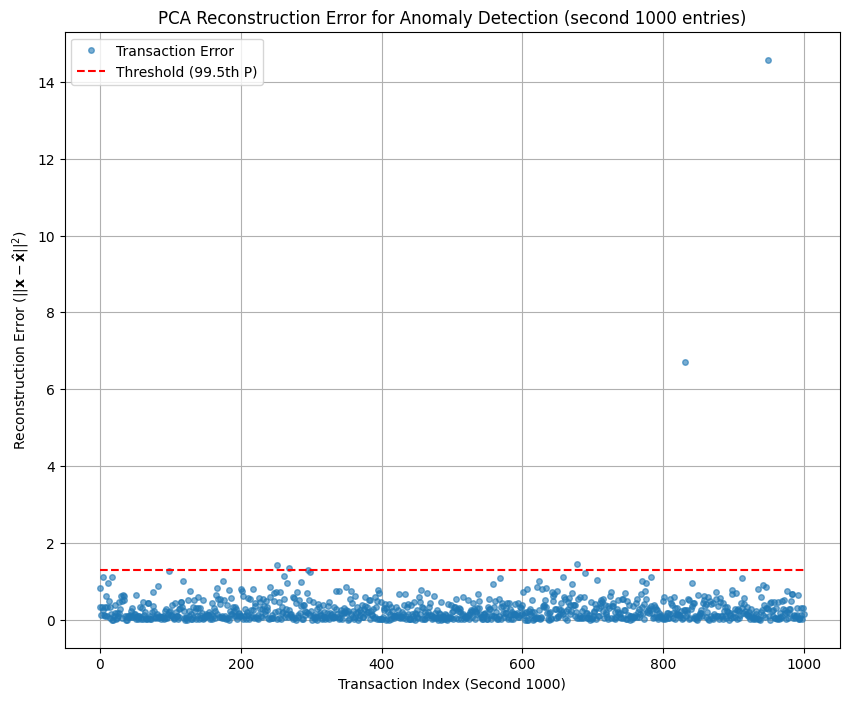

In [ ]:
cols_to_scale = [
    "Energy_Demand_MWh", "Emission_Produced_tCO2", "Emission_Allowance_tCO2",
    "Carbon_Price_USD_per_t", "Credits_Traded_tCO2",
    "Compliance_Cost_USD", "Carbon_Cost_Savings_USD"
]

df_temp = df.copy()

# log transform
for col in cols_to_scale:
    df_temp[col] = np.log1p(df_temp[col])

# data splits
df_first = df_temp.iloc[:1000]
df_second = df_temp.iloc[1000:2000]

# fit on the first 1000 data points
scaler = StandardScaler()
X_first_scaled = scaler.fit_transform(df_first[cols_to_scale])
pca = PCA(n_components=5)
X_first_pca = pca.fit_transform(X_first_scaled)

# apply to second 1000 data points
X_second_scaled = scaler.transform(df_second[cols_to_scale])
X_second_pca = pca.transform(X_second_scaled)
X_reconstructed = pca.inverse_transform(X_second_pca)
reconstruction_error = np.sum(np.square(X_second_scaled - X_reconstructed), axis=1)

# detect anomalies
threshold_percentile = 99.5
error_threshold = np.percentile(reconstruction_error, threshold_percentile)
is_anomaly = reconstruction_error > error_threshold
indices = [i for i, val in enumerate(is_anomaly) if val]
print([1000 + i for i, val in enumerate(is_anomaly) if val])

print(f"Total Transactions: {len(X_second_pca)}")
print(f"Reconstruction Error Threshold (P{threshold_percentile}): {error_threshold:.2f}")
print(f"Number of Detected Anomalies: {np.sum(is_anomaly)}")
plt.figure(figsize=(10, 8))
plt.plot(reconstruction_error, marker='o', markersize=4, linestyle='', alpha=0.6, label='Transaction Error')
plt.hlines(error_threshold, xmin=0, xmax=len(X_second_pca), color='r', linestyle='--',
           label=f'Threshold ({threshold_percentile}th P)')
plt.title('PCA Reconstruction Error for Anomaly Detection (second 1000 entries)')
plt.xlabel('Transaction Index (Second 1000)')
plt.ylabel(r'Reconstruction Error ($||\mathbf{x} - \mathbf{\hat{x}}||^2$)')
plt.legend()
plt.grid(True)
plt.show()

``` second split: [0:2000] [2000:3000] ```

[2166, 2183, 2207, 2504, 2706]
Total Transactions: 1000
Reconstruction Error Threshold (P99.5): 1.55
Number of Detected Anomalies: 5


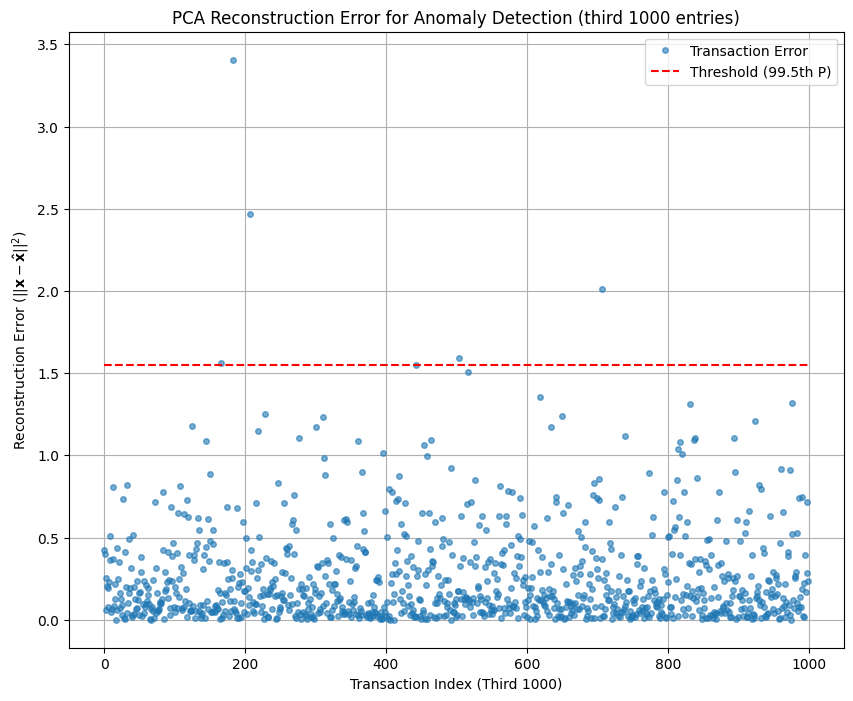

In [ ]:
cols_to_scale = [
    "Energy_Demand_MWh", "Emission_Produced_tCO2", "Emission_Allowance_tCO2",
    "Carbon_Price_USD_per_t", "Credits_Traded_tCO2",
    "Compliance_Cost_USD", "Carbon_Cost_Savings_USD"
]

df_temp = df.copy()

# log transform
for col in cols_to_scale:
    df_temp[col] = np.log1p(df_temp[col])

# data splits
df_first = df_temp.iloc[:2000]
df_second = df_temp.iloc[2000:3000]

# fit on the first 1000 data points
scaler = StandardScaler()
X_first_scaled = scaler.fit_transform(df_first[cols_to_scale])
pca = PCA(n_components=5)
X_first_pca = pca.fit_transform(X_first_scaled)

# apply to second 1000 data points
X_second_scaled = scaler.transform(df_second[cols_to_scale])
X_second_pca = pca.transform(X_second_scaled)
X_reconstructed = pca.inverse_transform(X_second_pca)
reconstruction_error = np.sum(np.square(X_second_scaled - X_reconstructed), axis=1)

# detect anomalies
threshold_percentile = 99.5
error_threshold = np.percentile(reconstruction_error, threshold_percentile)
is_anomaly = reconstruction_error > error_threshold
indices = [i for i, val in enumerate(is_anomaly) if val]
print([2000 + i for i, val in enumerate(is_anomaly) if val])

print(f"Total Transactions: {len(X_second_pca)}")
print(f"Reconstruction Error Threshold (P{threshold_percentile}): {error_threshold:.2f}")
print(f"Number of Detected Anomalies: {np.sum(is_anomaly)}")
plt.figure(figsize=(10, 8))
plt.plot(reconstruction_error, marker='o', markersize=4, linestyle='', alpha=0.6, label='Transaction Error')
plt.hlines(error_threshold, xmin=0, xmax=len(X_second_pca), color='r', linestyle='--',
           label=f'Threshold ({threshold_percentile}th P)')
plt.title('PCA Reconstruction Error for Anomaly Detection (third 1000 entries)')
plt.xlabel('Transaction Index (Third 1000)')
plt.ylabel(r'Reconstruction Error ($||\mathbf{x} - \mathbf{\hat{x}}||^2$)')
plt.legend()
plt.grid(True)
plt.show()

``` this is [0:3000] and [3000:4000]```

In [ ]:
df

,Company_ID,Date,Energy_Demand_MWh,Emission_Produced_tCO2,Emission_Allowance_tCO2,Carbon_Price_USD_per_t,Credits_Traded_tCO2,Compliance_Cost_USD,Carbon_Cost_Savings_USD,Target_Trade_Action,...,Fuel_Type_Mixed Fuel,Fuel_Type_Natural Gas,Fuel_Type_Renewable,Transaction_Type_Buy,Transaction_Type_Sell,Verification_Status_Disputed,Verification_Status_Verified,Optimization_Scenario_High_Demand,Optimization_Scenario_Low_Demand,Optimization_Scenario_Price_Surge
1107,C033,2024-01-01,1725.44,1164.27,1181.27,22.42,165,7094.64,2045.22,1,...,False,False,True,True,False,False,True,True,False,False
559,C086,2024-01-01,2114.09,988.02,964.02,31.14,41,10865.67,893.75,1,...,False,True,False,True,False,False,True,False,False,True
4848,C096,2024-01-01,646.63,210.49,241.49,27.27,53,18491.80,2640.20,0,...,True,False,False,False,True,False,True,False,False,True
3257,C022,2024-01-01,1060.05,419.74,474.74,33.52,141,11179.34,2598.28,1,...,False,False,True,True,False,True,False,True,False,False
274,C027,2024-01-01,2851.41,1450.95,1369.95,30.95,30,9303.50,2655.93,0,...,True,False,False,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,C058,2025-12-31,842.76,533.95,350.95,24.57,88,14267.78,977.69,1,...,True,False,False,True,False,False,True,False,False,True
1140,C061,2025-12-31,1321.28,609.30,799.30,34.55,91,7686.45,1393.14,0,...,False,False,True,False,True,True,False,False,False,True
1500,C092,2025-12-31,2394.34,870.96,726.96,31.59,177,7228.84,2686.09,1,...,False,False,False,True,False,False,True,False,True,False
4827,C051,2025-12-31,2667.80,1564.28,1475.28,29.90,183,6944.08,2374.54,0,...,False,False,False,False,True,False,True,False,False,True


[3035, 3048, 3217, 3247, 3601]
Total Transactions: 1000
Reconstruction Error Threshold (P99.5): 1.23
Number of Detected Anomalies: 5


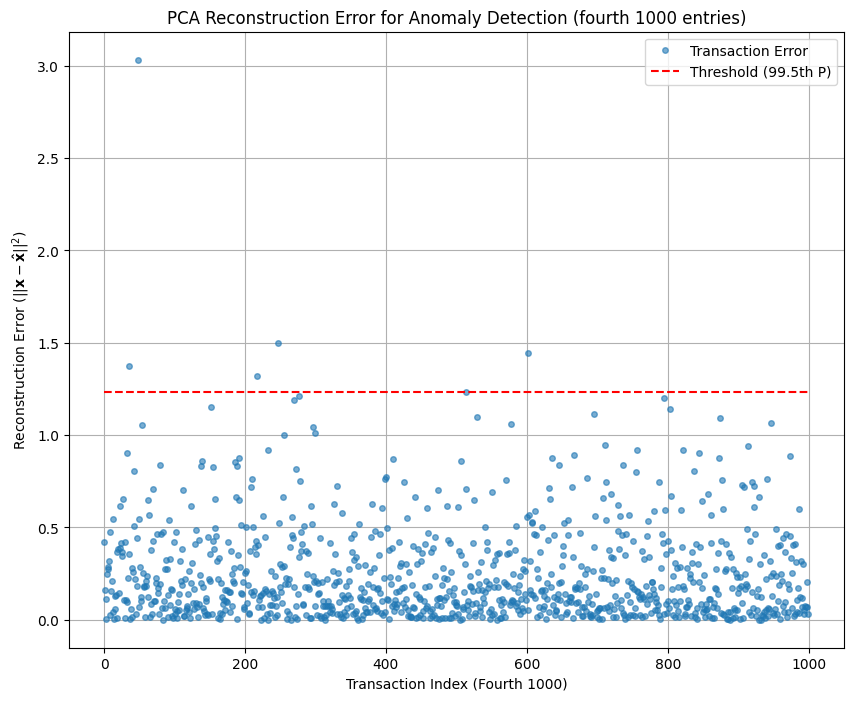

In [ ]:
cols_to_scale = [
    "Energy_Demand_MWh", "Emission_Produced_tCO2", "Emission_Allowance_tCO2",
    "Carbon_Price_USD_per_t", "Credits_Traded_tCO2",
    "Compliance_Cost_USD", "Carbon_Cost_Savings_USD"
]

df_temp = df.copy()

# log transform
for col in cols_to_scale:
    df_temp[col] = np.log1p(df_temp[col])

# data splits
df_first = df_temp.iloc[:3000]
df_second = df_temp.iloc[3000:4000]

# fit on the first 1000 data points
scaler = StandardScaler()
X_first_scaled = scaler.fit_transform(df_first[cols_to_scale])
pca = PCA(n_components=5)
X_first_pca = pca.fit_transform(X_first_scaled)

# apply to second 1000 data points
X_second_scaled = scaler.transform(df_second[cols_to_scale])
X_second_pca = pca.transform(X_second_scaled)
X_reconstructed = pca.inverse_transform(X_second_pca)
reconstruction_error = np.sum(np.square(X_second_scaled - X_reconstructed), axis=1)

# detect anomalies
threshold_percentile = 99.5
error_threshold = np.percentile(reconstruction_error, threshold_percentile)
is_anomaly = reconstruction_error > error_threshold
indices = [i for i, val in enumerate(is_anomaly) if val]
print([3000 + i for i, val in enumerate(is_anomaly) if val])

print(f"Total Transactions: {len(X_second_pca)}")
print(f"Reconstruction Error Threshold (P{threshold_percentile}): {error_threshold:.2f}")
print(f"Number of Detected Anomalies: {np.sum(is_anomaly)}")
plt.figure(figsize=(10, 8))
plt.plot(reconstruction_error, marker='o', markersize=4, linestyle='', alpha=0.6, label='Transaction Error')
plt.hlines(error_threshold, xmin=0, xmax=len(X_second_pca), color='r', linestyle='--',
           label=f'Threshold ({threshold_percentile}th P)')
plt.title('PCA Reconstruction Error for Anomaly Detection (fourth 1000 entries)')
plt.xlabel('Transaction Index (Fourth 1000)')
plt.ylabel(r'Reconstruction Error ($||\mathbf{x} - \mathbf{\hat{x}}||^2$)')
plt.legend()
plt.grid(True)
plt.show()

``` this is now [0:4000] and now looking at [4000:5000] ```

[4175, 4371, 4385, 4697, 4941]
Total Transactions: 1000
Reconstruction Error Threshold (P99.5): 2.29
Number of Detected Anomalies: 5


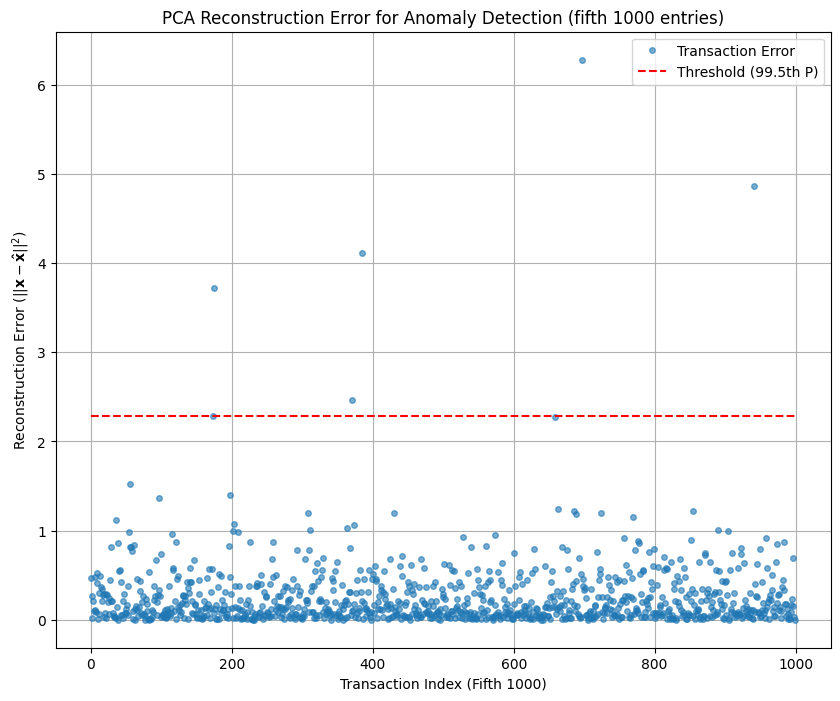

In [ ]:
cols_to_scale = [
    "Energy_Demand_MWh", "Emission_Produced_tCO2", "Emission_Allowance_tCO2",
    "Carbon_Price_USD_per_t", "Credits_Traded_tCO2",
    "Compliance_Cost_USD", "Carbon_Cost_Savings_USD"
]

df_temp = df.copy()

# log transform
for col in cols_to_scale:
    df_temp[col] = np.log1p(df_temp[col])

# data splits
df_first = df_temp.iloc[:4000]
df_second = df_temp.iloc[4000:5000]

# fit on the first 1000 data points
scaler = StandardScaler()
X_first_scaled = scaler.fit_transform(df_first[cols_to_scale])
pca = PCA(n_components=5)
X_first_pca = pca.fit_transform(X_first_scaled)

# apply to second 1000 data points
X_second_scaled = scaler.transform(df_second[cols_to_scale])
X_second_pca = pca.transform(X_second_scaled)
X_reconstructed = pca.inverse_transform(X_second_pca)
reconstruction_error = np.sum(np.square(X_second_scaled - X_reconstructed), axis=1)

# detect anomalies
threshold_percentile = 99.5
error_threshold = np.percentile(reconstruction_error, threshold_percentile)
is_anomaly = reconstruction_error > error_threshold
indices = [i for i, val in enumerate(is_anomaly) if val]
print([4000 + i for i, val in enumerate(is_anomaly) if val])

print(f"Total Transactions: {len(X_second_pca)}")
print(f"Reconstruction Error Threshold (P{threshold_percentile}): {error_threshold:.2f}")
print(f"Number of Detected Anomalies: {np.sum(is_anomaly)}")
plt.figure(figsize=(10, 8))
plt.plot(reconstruction_error, marker='o', markersize=4, linestyle='', alpha=0.6, label='Transaction Error')
plt.hlines(error_threshold, xmin=0, xmax=len(X_second_pca), color='r', linestyle='--',
           label=f'Threshold ({threshold_percentile}th P)')
plt.title('PCA Reconstruction Error for Anomaly Detection (fifth 1000 entries)')
plt.xlabel('Transaction Index (Fifth 1000)')
plt.ylabel(r'Reconstruction Error ($||\mathbf{x} - \mathbf{\hat{x}}||^2$)')
plt.legend()
plt.grid(True)
plt.show()

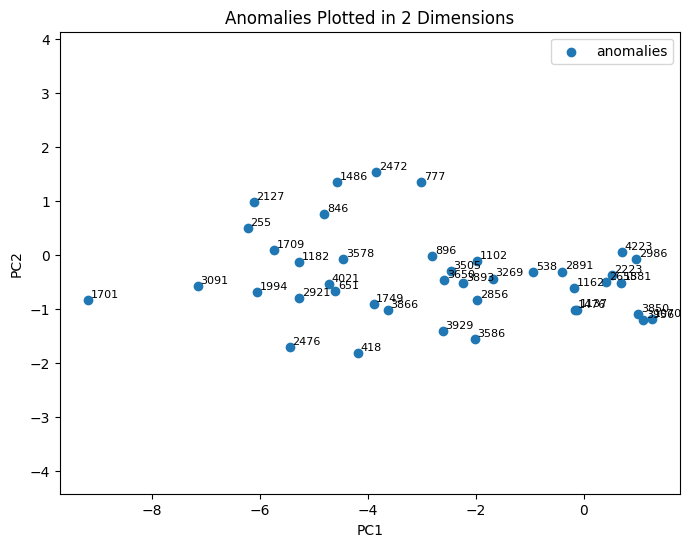

In [ ]:
cols_to_scale = [
    "Energy_Demand_MWh", "Emission_Produced_tCO2", "Emission_Allowance_tCO2",
    "Carbon_Price_USD_per_t", "Credits_Traded_tCO2",
    "Compliance_Cost_USD", "Carbon_Cost_Savings_USD"
]

df_temp = df.copy()

for col in cols_to_scale:
    df_temp[col] = np.log1p(df_temp[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_temp[cols_to_scale])


pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

pc_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_names, index=df.index)

df_remaining = df.drop(columns=cols_to_scale)
df_final = pd.concat([df_remaining, df_pca], axis=1)

df_anomalies = df_final.iloc[[46, 516, 702, 775, 1251, 1269, 1464, 1602, 1662, 1678, 1721, 1831,
                               1948, 2166, 2183, 2207, 2328, 2504, 2517, 2539, 2648, 2706, 2796, 2982,
                               2996, 3035, 3048, 3217, 3247, 3482, 3601, 3775, 3832, 4055, 4150, 4175,
                               4371, 4385, 4697, 4795, 4941]]

df_anomalies_scientific_data = df_temp[cols_to_scale].iloc[[46, 516, 702, 775, 1251, 1269, 1464, 1602, 1662, 1678, 1721, 1831,
                               1948, 2166, 2183, 2207, 2328, 2504, 2517, 2539, 2648, 2706, 2796, 2982,
                               2996, 3035, 3048, 3217, 3247, 3482, 3601, 3775, 3832, 4055, 4150, 4175,
                               4371, 4385, 4697, 4795, 4941]]
# yes this is correct, because i sorted it in time order yes we are
# it shuold be 1701 538 etc

plt.figure(figsize=(8, 6))
plt.scatter(df_anomalies["PC1"], df_anomalies["PC2"], label='anomalies')
for i, idx in enumerate(df_anomalies.index):
    plt.text(df_anomalies["PC1"].iloc[i] + 0.05, df_anomalies["PC2"].iloc[i] + 0.05, str(idx),
             fontsize=8, color='black')
plt.axis('equal')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalies Plotted in 2 Dimensions")
plt.legend()
plt.show()

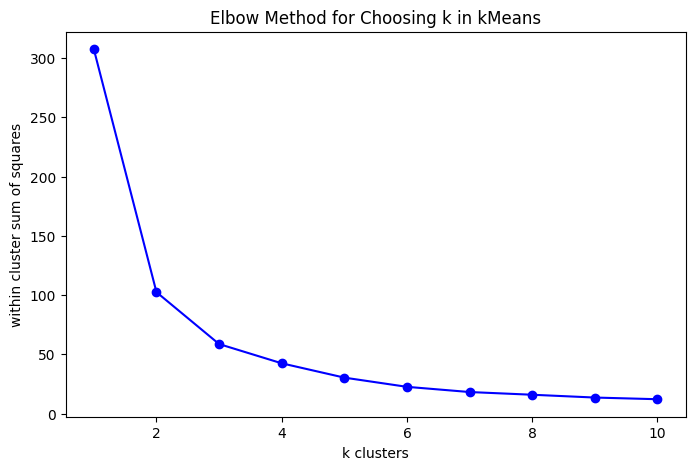

In [ ]:
X = df_anomalies[["PC1", "PC2"]].values
wcss = []
K = range(1, 11)  # test 1 to 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, wcss, 'bo-')
plt.xlabel('k clusters')
plt.ylabel('within cluster sum of squares')
plt.title('Elbow Method for Choosing k in kMeans')
plt.show()

/tmp/ipython-input-4285963169.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anomalies['cluster'] = kmeans_anom.fit_predict(X_anom)
/tmp/ipython-input-4285963169.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', k)


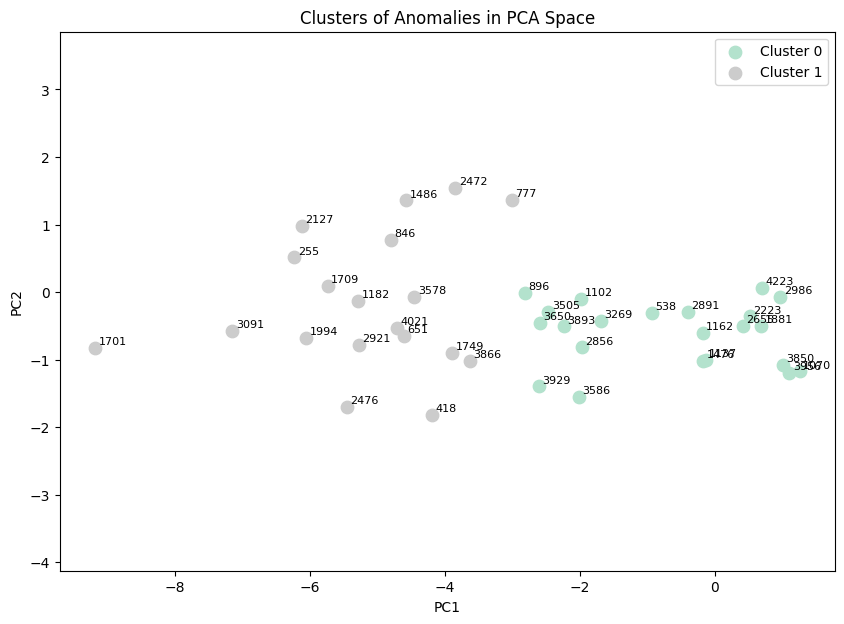

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_anom = df_anomalies[["PC1", "PC2"]].values

k = 2
kmeans_anom = KMeans(n_clusters=k, random_state=42, n_init=10)
df_anomalies['cluster'] = kmeans_anom.fit_predict(X_anom)

colors = plt.cm.get_cmap('Pastel2', k)

plt.figure(figsize=(10, 7))
for cluster in range(k):
    cluster_points = df_anomalies[df_anomalies['cluster'] == cluster]
    plt.scatter(cluster_points['PC1'], cluster_points['PC2'],
                color=colors(cluster), s=80, label=f'Cluster {cluster}')

x_offset = 0.05
y_offset = 0.05
for i, idx in enumerate(df_anomalies.index):
    plt.text(df_anomalies["PC1"].iloc[i] + x_offset,
             df_anomalies["PC2"].iloc[i] + y_offset,
             str(idx),
             fontsize=8, color='black')
plt.axis('equal')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters of Anomalies in PCA Space")
plt.legend()
plt.show()

The average silhouette score is: 0.5387


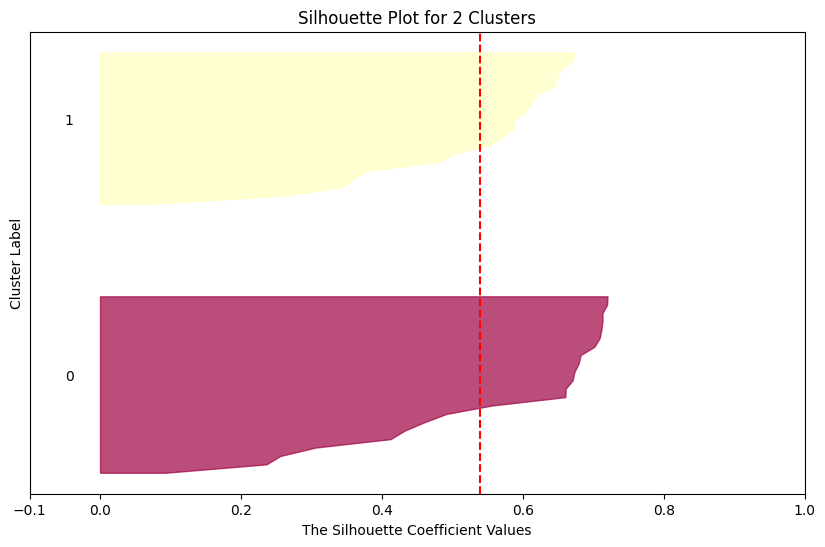

In [ ]:

# silhouette score for entire thing

silhouette_avg = silhouette_score(X_anom, df_anomalies['cluster'])
print(f"The average silhouette score is: {silhouette_avg:.4f}")
sample_silhouette_values = silhouette_samples(X_anom, df_anomalies['cluster'])
labels = df_anomalies['cluster']
n_clusters = 2

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))


ax1.set_xlim([-0.1, 1])


y_lower = 10

for i in range(n_clusters):
    # silhouette scores for samples belonging to each cluster
    ith_cluster_silhouette_values = \
        sample_silhouette_values[labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.Spectral(float(i) / n_clusters)

    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0,
                      ith_cluster_silhouette_values,
                      facecolor=color,
                      edgecolor=color,
                      alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10 # 10 for blank space

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_title(f"Silhouette Plot for {n_clusters} Clusters")
ax1.set_xlabel("The Silhouette Coefficient Values")
ax1.set_ylabel("Cluster Label")
ax1.set_yticks([])
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.show()

In [ ]:
df_anomalies_scientific_data['cluster'] = df_anomalies['cluster']
df_anomalies_scientific_data

,Energy_Demand_MWh,Emission_Produced_tCO2,Emission_Allowance_tCO2,Carbon_Price_USD_per_t,Credits_Traded_tCO2,Compliance_Cost_USD,Carbon_Cost_Savings_USD,cluster
1701,6.226813,5.271306,0.000000,3.464485,4.605170,8.525788,7.291111,1
538,7.408112,6.408018,6.106332,3.068518,3.332205,9.842775,7.623270,0
1881,7.829113,6.929321,6.741465,3.063391,3.178054,9.530973,7.854889,0
2655,7.413500,6.899622,6.855303,3.561614,3.135494,9.731806,6.346057,0
777,6.976665,5.854843,5.010102,3.285787,4.584967,9.888716,7.982614,1
3866,6.356628,5.171847,5.897813,3.223664,5.293305,8.737368,7.377634,1
2856,6.596368,6.027049,6.334150,3.415100,3.583519,9.778919,6.329739,0
3586,6.814960,5.999705,6.107713,3.075005,3.258097,9.887657,6.634870,0
2986,7.499744,7.204305,7.142203,3.118392,3.091042,9.727278,7.851568,0
3269,6.528046,6.285812,6.570743,3.086943,3.135494,9.796524,7.575072,0


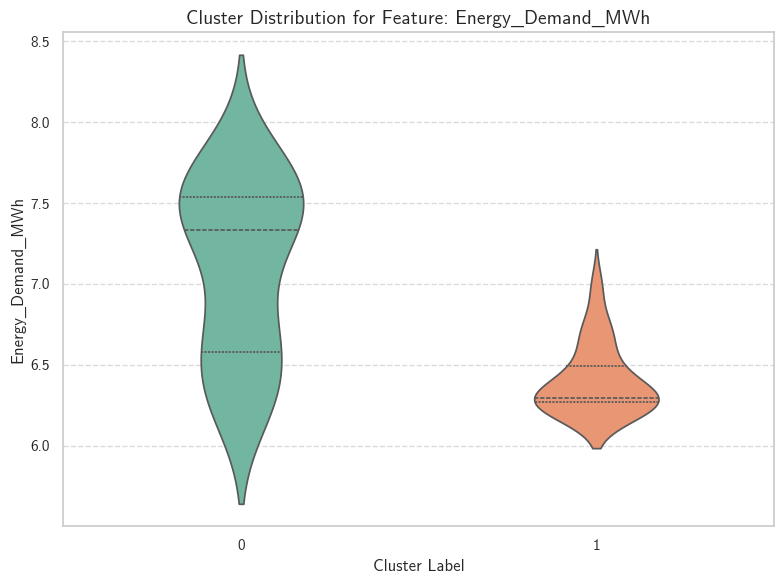

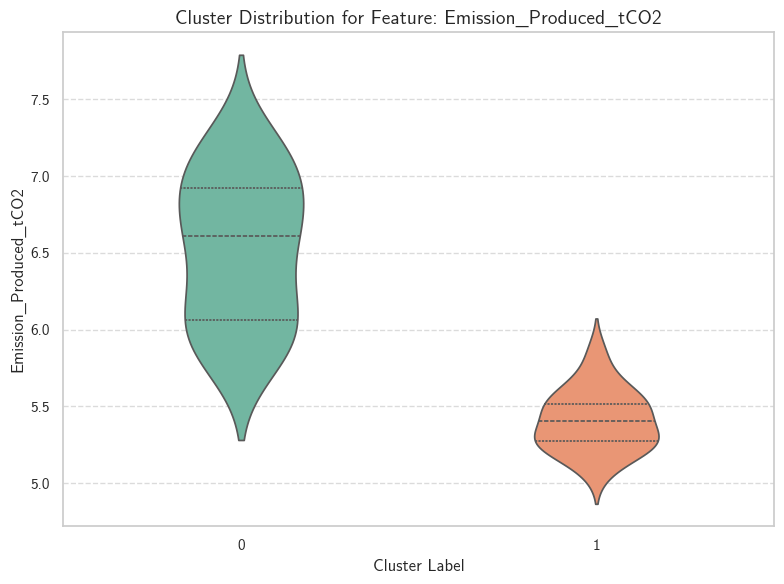

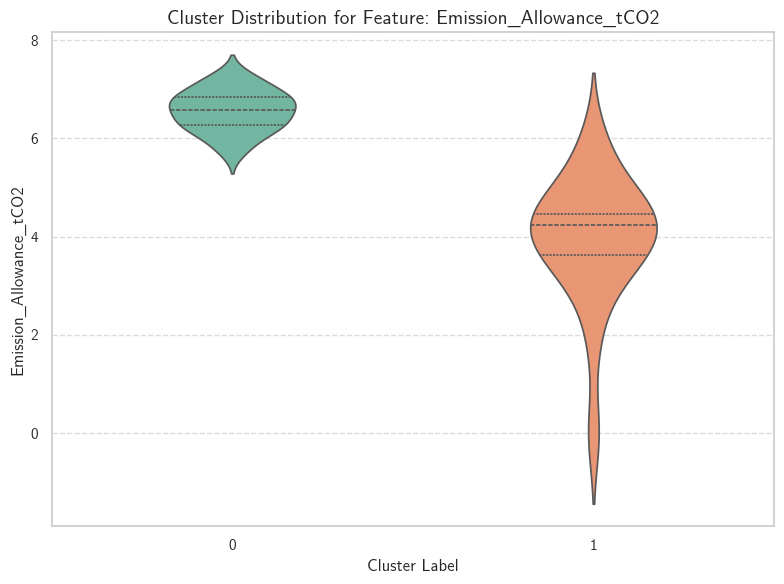

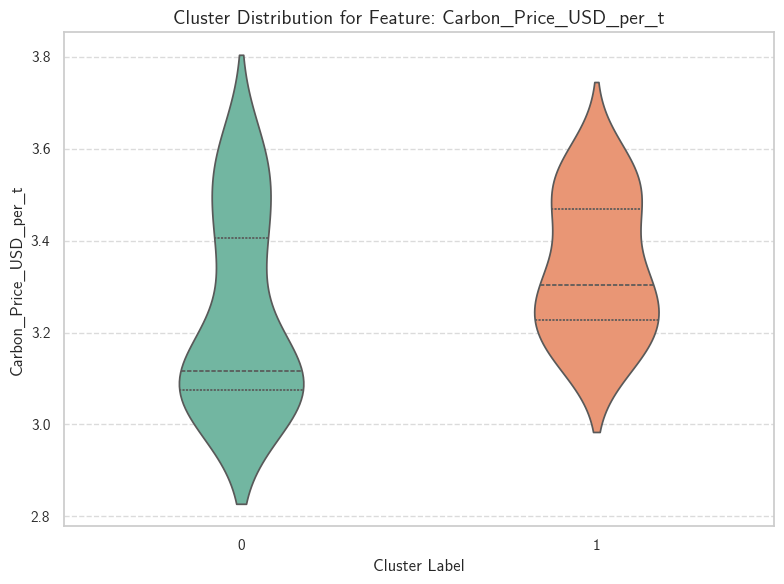

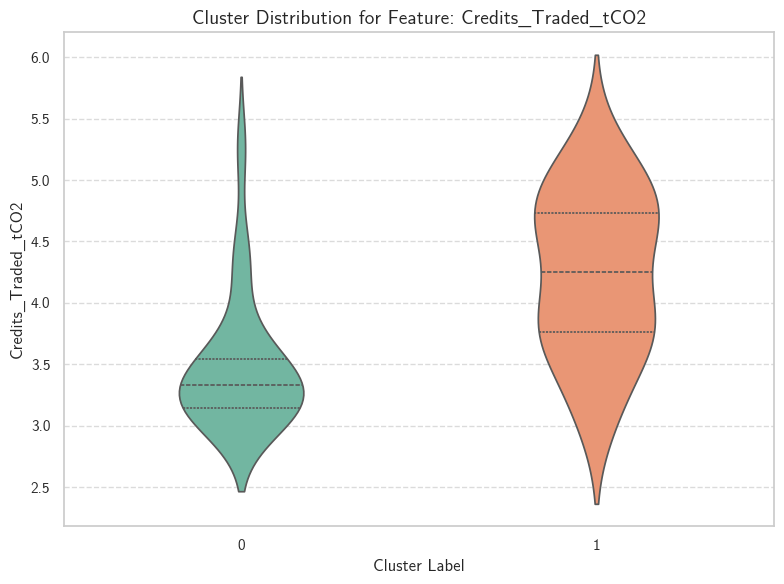

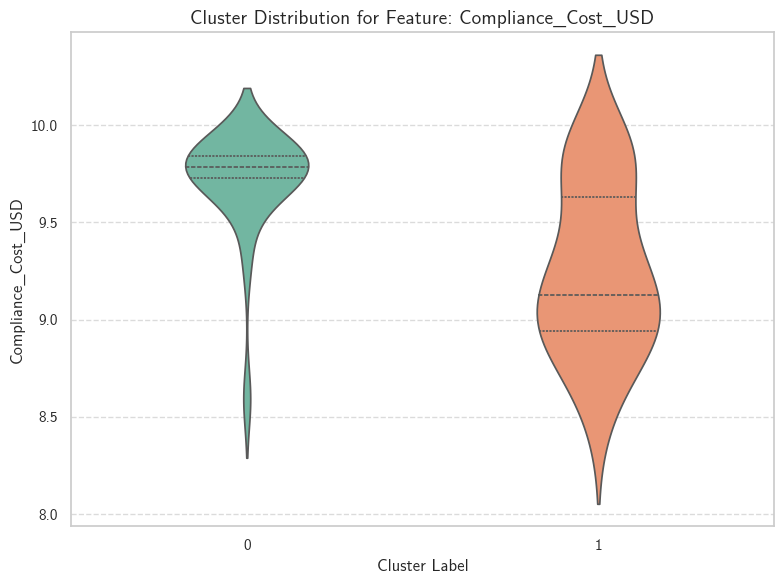

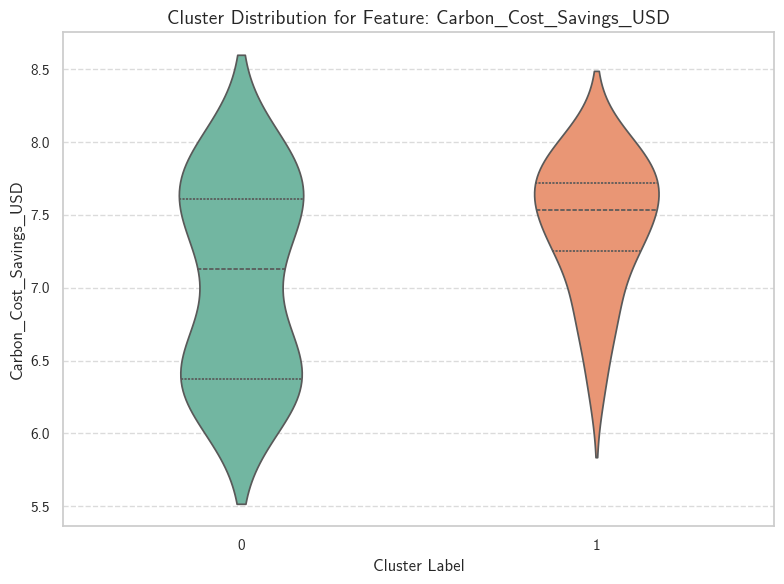

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

plt.rcParams["text.usetex"] = False
font_path = "/content/lmsans10-regular.otf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Latin Modern Sans"

exclude_cols = ['cluster']
feature_cols = [
    col for col in df_anomalies_scientific_data.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(df_anomalies_scientific_data[col])
]

n_clusters = df_anomalies_scientific_data['cluster'].nunique()
palette = sns.color_palette("Set2", n_clusters)

for feature in feature_cols:
    plt.figure(figsize=(8, 6))
    sns.violinplot(
        x='cluster',
        y=feature,
        data=df_anomalies_scientific_data,
        hue='cluster',
        palette=palette,
        inner='quartile',
        legend=False,
        width=0.35
    )

    plt.title(f'Cluster Distribution for Feature: {feature}', fontsize=14)
    plt.xlabel('Cluster Label', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
# df_anomalies_scientific_data has data for these 7 numerical features
# df is the originals

rows_to_keep_mask = ~df.index.isin([46, 516, 702, 775, 1251, 1269, 1464, 1602, 1662, 1678, 1721, 1831,
                               1948, 2166, 2183, 2207, 2328, 2504, 2517, 2539, 2648, 2706, 2796, 2982,
                               2996, 3035, 3048, 3217, 3247, 3482, 3601, 3775, 3832, 4055, 4150, 4175,
                               4371, 4385, 4697, 4795, 4941])

df_excluded_anoms = df.loc[rows_to_keep_mask]

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_anomalies_scientific_data2 = df.iloc[[46, 516, 702, 775, 1251, 1269, 1464, 1602, 1662, 1678, 1721, 1831,
                               1948, 2166, 2183, 2207, 2328, 2504, 2517, 2539, 2648, 2706, 2796, 2982,
                               2996, 3035, 3048, 3217, 3247, 3482, 3601, 3775, 3832, 4055, 4150, 4175,
                               4371, 4385, 4697, 4795, 4941]]

columns_to_test = [
    'Energy_Demand_MWh', 'Emission_Produced_tCO2', 'Emission_Allowance_tCO2',
    'Carbon_Price_USD_per_t', 'Credits_Traded_tCO2', 'Compliance_Cost_USD',
    'Carbon_Cost_Savings_USD'
]
alpha = 0.05
test_results = []

for col in columns_to_test:
    try:
        anomaly_values = df_anomalies_scientific_data2[col].dropna()
        non_anomaly_values = df_excluded_anoms[col].dropna()
    except KeyError:
        test_results.append({
            'Metric': col, 'U_Statistic': np.nan, 'P_Value': np.nan,
            'N_Anomalies': 0, 'N_NonAnomalies': 0, 'Conclusion': 'Column Not Found'
        })
        continue

    # this is check for sufficient data
    if len(anomaly_values) < 5 or len(non_anomaly_values) < 5:
        test_results.append({
            'Metric': col, 'U_Statistic': np.nan, 'P_Value': np.nan,
            'N_Anomalies': len(anomaly_values), 'N_NonAnomalies': len(non_anomaly_values),
            'Conclusion': 'Insufficient Data (N < 5)'
        })
        continue

    # mann whitney
    u_statistic, p_value = mannwhitneyu(
        x=anomaly_values,
        y=non_anomaly_values,
        alternative='two-sided'
    )


    if p_value < alpha:
        conclusion = "Significantly Different (Reject H0)"
    else:
        conclusion = "No Significant Difference (Fail to Reject H0)"


    test_results.append({
        'Metric': col,
        'U_Statistic': round(u_statistic, 2),
        'P_Value': round(p_value, 4),
        'N_Anomalies': len(anomaly_values),
        'N_NonAnomalies': len(non_anomaly_values),
        'Conclusion': conclusion
    })

results_df = pd.DataFrame(test_results)
print("--- Mann-Whitney U Test Summary Table ---")

# visualise ts
df_anomalies_scientific_data2['Group'] = 'Anomaly'
df_excluded_anoms['Group'] = 'Non-Anomaly'

df_combined = pd.concat([df_anomalies_scientific_data2, df_excluded_anoms], ignore_index=True)

df_combined_melt = pd.melt(
    df_combined,
    id_vars=['Group'],
    value_vars=columns_to_test,
    var_name='Metric',
    value_name='Value'
)

results_df

--- Mann-Whitney U Test Summary Table ---


/tmp/ipython-input-2732876077.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anomalies_scientific_data2['Group'] = 'Anomaly'
/tmp/ipython-input-2732876077.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_excluded_anoms['Group'] = 'Non-Anomaly'


,Metric,U_Statistic,P_Value,N_Anomalies,N_NonAnomalies,Conclusion
0,Energy_Demand_MWh,42663.5,0.0000,41,4959,Significantly Different (Reject H0)
1,Emission_Produced_tCO2,42952.5,0.0000,41,4959,Significantly Different (Reject H0)
2,Emission_Allowance_tCO2,43931.0,0.0000,41,4959,Significantly Different (Reject H0)
3,Carbon_Price_USD_per_t,83571.0,0.0494,41,4959,Significantly Different (Reject H0)
4,Credits_Traded_tCO2,44353.0,0.0000,41,4959,Significantly Different (Reject H0)
5,Compliance_Cost_USD,126760.5,0.0064,41,4959,Significantly Different (Reject H0)
6,Carbon_Cost_Savings_USD,89941.0,0.2030,41,4959,No Significant Difference (Fail to Reject H0)


/tmp/ipython-input-671728838.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-671728838.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-671728838.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-671728838.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-671728838.py:21: FutureWarning: 

Passing `pa

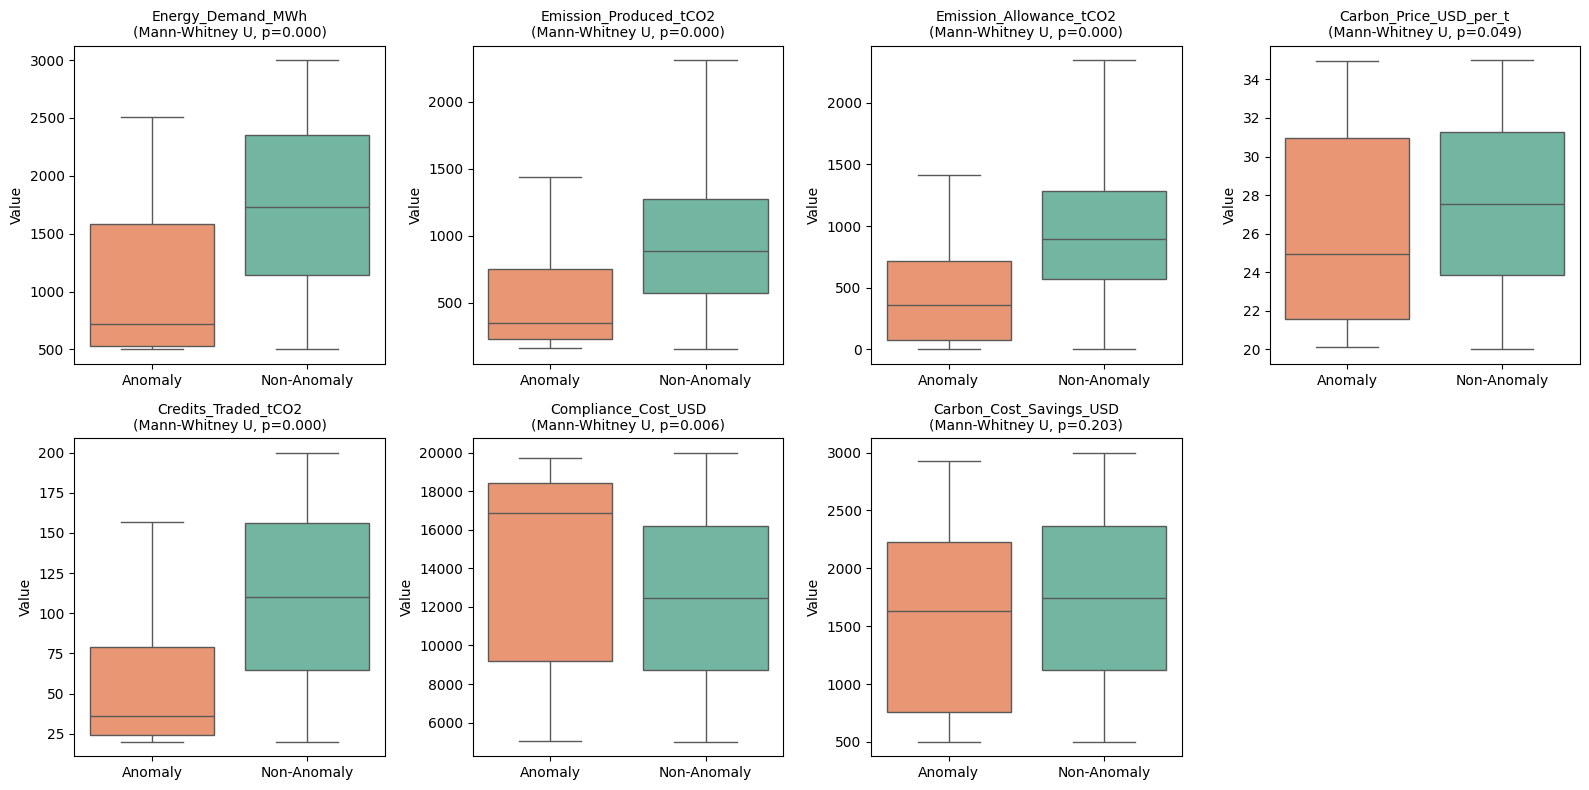

In [ ]:

num_plots = len(columns_to_test)
rows = int(np.ceil(num_plots / 4))
cols = 4 if num_plots > 4 else num_plots
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

# p-values from the results table
for i, col in enumerate(columns_to_test):
    plot_data = df_combined_melt[df_combined_melt['Metric'] == col]

    summary_row = results_df[results_df['Metric'] == col].iloc[0]
    p_value = summary_row['P_Value']

    sns.boxplot(
        x='Group',
        y='Value',
        data=plot_data,
        ax=axes[i],
        palette={'Anomaly': sns.color_palette("Set2")[1], 'Non-Anomaly': sns.color_palette("Set2")[0]},
        showfliers=False
    )


    if not pd.isna(p_value):
        axes[i].set_title(f"{col}\n(Mann-Whitney U, p={p_value:.3f})", fontsize=10)
    else:
        axes[i].set_title(f"{col}\n(Test Skipped/Error)", fontsize=10)

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")

for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
df_anomalies_scientific_data2

,Company_ID,Date,Energy_Demand_MWh,Emission_Produced_tCO2,Emission_Allowance_tCO2,Carbon_Price_USD_per_t,Credits_Traded_tCO2,Compliance_Cost_USD,Carbon_Cost_Savings_USD,Target_Trade_Action,...,Fuel_Type_Natural Gas,Fuel_Type_Renewable,Transaction_Type_Buy,Transaction_Type_Sell,Verification_Status_Disputed,Verification_Status_Verified,Optimization_Scenario_High_Demand,Optimization_Scenario_Low_Demand,Optimization_Scenario_Price_Surge,Group
1701,C031,2024-01-06,505.14,193.67,0.00,30.96,99,5042.16,1466.20,1,...,False,False,True,False,False,True,True,False,False,Anomaly
538,C092,2024-03-15,1648.31,605.69,447.69,20.51,27,18820.87,2044.24,1,...,True,False,True,False,True,False,False,True,False,Anomaly
1881,C091,2024-04-09,2511.70,1020.80,845.80,20.40,23,13778.99,2577.31,0,...,True,False,False,True,False,True,True,False,False,Anomaly
2655,C081,2024-04-20,1657.22,990.90,947.90,34.22,22,16843.95,569.24,0,...,False,False,False,True,True,False,True,False,False,Anomaly
777,C022,2024-06-26,1070.34,347.92,148.92,25.73,97,19705.74,2928.58,1,...,False,False,True,False,False,True,True,False,False,Anomaly
3866,C030,2024-06-29,575.30,175.24,363.24,24.12,198,6230.47,1598.80,0,...,True,False,False,True,True,False,False,False,True,Anomaly
2856,C072,2024-07-24,731.43,413.49,562.49,29.42,35,17656.56,560.01,0,...,False,False,False,True,True,False,True,False,False,Anomaly
3586,C034,2024-08-13,910.38,402.31,448.31,20.65,25,19684.89,760.18,0,...,False,False,False,True,True,False,False,False,True,Anomaly
2986,C053,2024-08-21,1806.58,1344.21,1263.21,21.61,21,16767.85,2568.76,1,...,False,True,True,False,False,True,False,False,True,Anomaly
3269,C071,2024-08-23,683.06,535.90,712.90,20.91,22,17970.16,1948.00,1,...,False,False,True,False,True,False,False,False,True,Anomaly


```most of the stuff after this is old and incorrect !!! (i.e., 3 clusters, global anomalies)```

/tmp/ipython-input-949758124.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anomalies['cluster'] = kmeans_anom.fit_predict(X_anom)
/tmp/ipython-input-949758124.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', k)


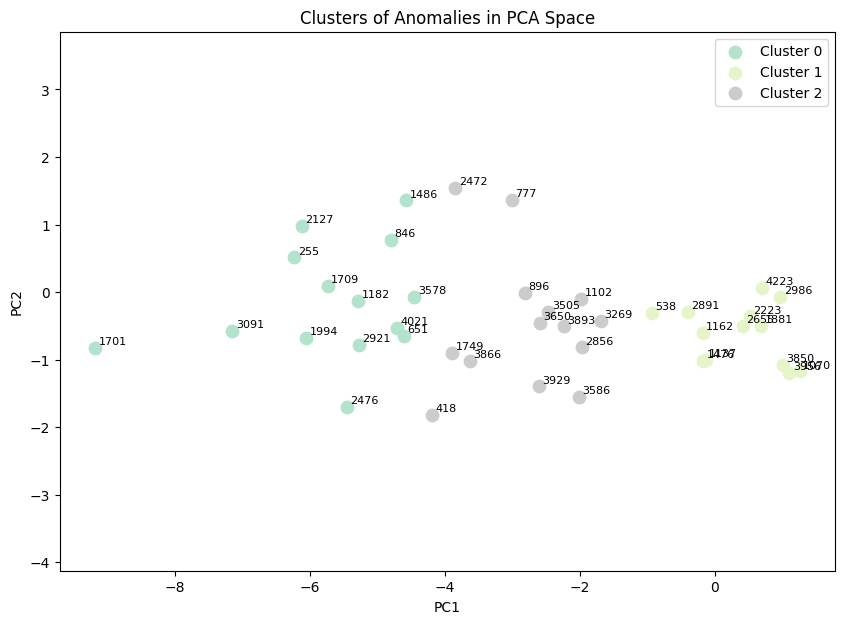

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


X_anom = df_anomalies[["PC1", "PC2"]].values

k = 3
kmeans_anom = KMeans(n_clusters=k, random_state=42, n_init=10)
df_anomalies['cluster'] = kmeans_anom.fit_predict(X_anom)

colors = plt.cm.get_cmap('Pastel2', k)

plt.figure(figsize=(10, 7))
for cluster in range(k):
    cluster_points = df_anomalies[df_anomalies['cluster'] == cluster]
    plt.scatter(cluster_points['PC1'], cluster_points['PC2'],
                color=colors(cluster), s=80, label=f'Cluster {cluster}')

x_offset = 0.05
y_offset = 0.05
for i, idx in enumerate(df_anomalies.index):
    plt.text(df_anomalies["PC1"].iloc[i] + x_offset,
             df_anomalies["PC2"].iloc[i] + y_offset,
             str(idx),
             fontsize=8, color='black')
plt.axis('equal')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters of Anomalies in PCA Space")
plt.legend()
plt.show()

The average silhouette score is: 0.4841


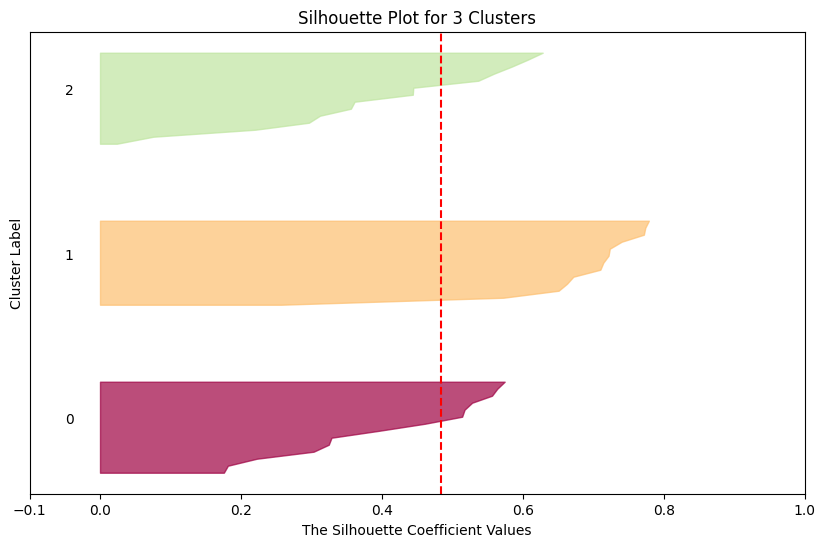

In [ ]:

# silhouette score for entire thing

silhouette_avg = silhouette_score(X_anom, df_anomalies['cluster'])
print(f"The average silhouette score is: {silhouette_avg:.4f}")
sample_silhouette_values = silhouette_samples(X_anom, df_anomalies['cluster'])
labels = df_anomalies['cluster']
n_clusters = 3

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

ax1.set_xlim([-0.1, 1])

y_lower = 10

for i in range(n_clusters):
    ith_cluster_silhouette_values = \
        sample_silhouette_values[labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.Spectral(float(i) / n_clusters)

    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0,
                      ith_cluster_silhouette_values,
                      facecolor=color,
                      edgecolor=color,
                      alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10 # 10 for blank space

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_title(f"Silhouette Plot for {n_clusters} Clusters")
ax1.set_xlabel("The Silhouette Coefficient Values")
ax1.set_ylabel("Cluster Label")
ax1.set_yticks([])
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.show()

In [ ]:
# running silhouette scores

X_anom = df_anomalies[["PC1", "PC2"]].values

k = [2, 3, 4, 5, 6, 7]

for index, num in enumerate(k):
  kmeans_anom = KMeans(n_clusters=num, random_state=42, n_init=10)
  anoms = kmeans_anom.fit_predict(X_anom)
  silhouette_avg = silhouette_score(X_anom, anoms)
  print(f"The average silhouette score for {num} clusters is: {silhouette_avg:.4f}")


The average silhouette score for 2 clusters is: 0.5387
The average silhouette score for 3 clusters is: 0.4841
The average silhouette score for 4 clusters is: 0.4758
The average silhouette score for 5 clusters is: 0.4817
The average silhouette score for 6 clusters is: 0.4791
The average silhouette score for 7 clusters is: 0.4209


# eda things

Text(0.5, 1.0, 'Scree Plot (Explained Variance per PC)')

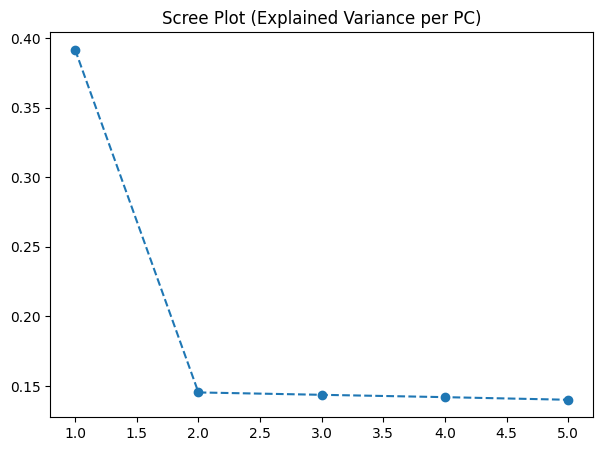

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, marker='o', linestyle='--')

plt.title("Scree Plot (Explained Variance per PC)")

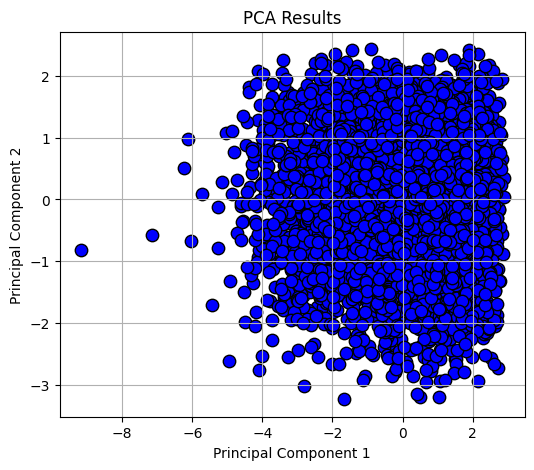

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c="blue", edgecolor="k", s=80)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Results")
plt.grid(True)
plt.show()

<Axes: xlabel='PC1', ylabel='PC2'>

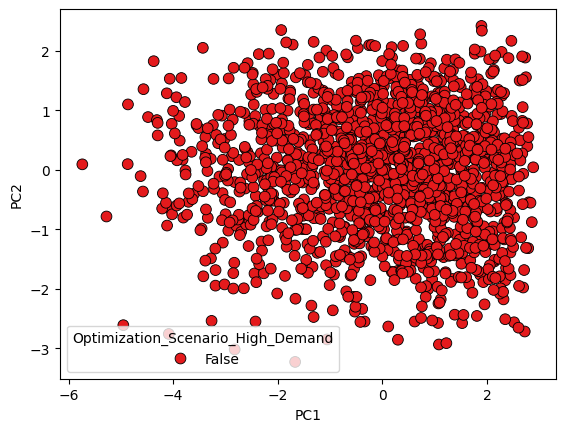

In [ ]:
import seaborn as sns

df_pca_plot = df_final.copy()
sns.scatterplot(
    data=df_pca_plot[df_pca_plot["Optimization_Scenario_Low_Demand"] == True], x="PC1", y="PC2",
    hue="Optimization_Scenario_High_Demand", palette="Set1", s=60, edgecolor="k"
)

Total Transactions: 5000
Reconstruction Error Threshold (P99.5): 8.84
Number of Detected Anomalies: 25


<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1423615939.py:28: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Reconstruction Error ($||\mathbf{x} - \mathbf{\hat{x}}||^2$)')


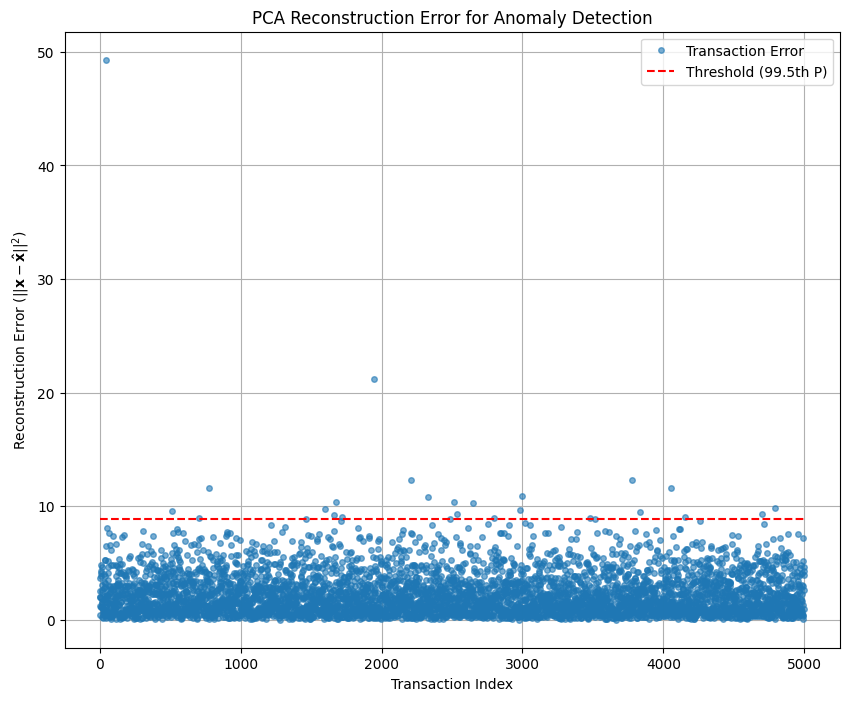

In [ ]:
# this one is on global - i did this on 10/1 presentation, which prof said to modify

X_reconstructed = pca.inverse_transform(X_pca)

reconstruction_error = np.sum(np.square(X_scaled - X_reconstructed), axis=1)

threshold_percentile = 99.5
error_threshold = np.percentile(reconstruction_error, threshold_percentile)

is_anomaly = reconstruction_error > error_threshold

print(f"Total Transactions: {len(X_pca)}")
print(f"Reconstruction Error Threshold (P{threshold_percentile}): {error_threshold:.2f}")
print(f"Number of Detected Anomalies: {np.sum(is_anomaly)}")

plt.figure(figsize=(10, 8))
plt.plot(reconstruction_error, marker='o', markersize=4, linestyle='', alpha=0.6, label='Transaction Error')
plt.hlines(error_threshold, xmin=0, xmax=len(X_pca), color='r', linestyle='--', label=f'Threshold ({threshold_percentile}th P)')
plt.title('PCA Reconstruction Error for Anomaly Detection')
plt.xlabel('Transaction Index')
plt.ylabel('Reconstruction Error ($||\mathbf{x} - \mathbf{\hat{x}}||^2$)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
indices = [i for i, val in enumerate(is_anomaly) if val]
print(indices)

[46, 516, 702, 775, 1464, 1602, 1662, 1678, 1721, 1948, 2207, 2328, 2517, 2539, 2648, 2796, 2982, 2996, 3482, 3775, 3832, 4055, 4150, 4697, 4795]


In [ ]:
df_dum.iloc[indices]
df_dum

,Company_ID,Industry_Type,Date,Energy_Demand_MWh,Fuel_Type,Emission_Produced_tCO2,Emission_Allowance_tCO2,Carbon_Price_USD_per_t,Transaction_Type,Credits_Traded_tCO2,Verification_Status,Compliance_Cost_USD,Optimization_Scenario,Carbon_Cost_Savings_USD,Target_Trade_Action
1107,C033,Manufacturing,2024-01-01,1725.44,Renewable,1164.27,1181.27,22.42,Buy,165,Verified,7094.64,High_Demand,2045.22,1
559,C086,Cement,2024-01-01,2114.09,Natural Gas,988.02,964.02,31.14,Buy,41,Verified,10865.67,Price_Surge,893.75,1
4848,C096,Cement,2024-01-01,646.63,Mixed Fuel,210.49,241.49,27.27,Sell,53,Verified,18491.80,Price_Surge,2640.20,0
3257,C022,Energy,2024-01-01,1060.05,Renewable,419.74,474.74,33.52,Buy,141,Disputed,11179.34,High_Demand,2598.28,1
274,C027,Cement,2024-01-01,2851.41,Mixed Fuel,1450.95,1369.95,30.95,Sell,30,Disputed,9303.50,Low_Demand,2655.93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48,C058,Manufacturing,2025-12-31,842.76,Mixed Fuel,533.95,350.95,24.57,Buy,88,Verified,14267.78,Price_Surge,977.69,1
1140,C061,Cement,2025-12-31,1321.28,Renewable,609.30,799.30,34.55,Sell,91,Disputed,7686.45,Price_Surge,1393.14,0
1500,C092,Energy,2025-12-31,2394.34,Coal,870.96,726.96,31.59,Buy,177,Verified,7228.84,Low_Demand,2686.09,1
4827,C051,Manufacturing,2025-12-31,2667.80,Coal,1564.28,1475.28,29.90,Sell,183,Verified,6944.08,Price_Surge,2374.54,0
